# Initialize Notebook

---

In [1]:
# Package imports
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the classes and helper functions from the PRIZM files
from src.PRIZM_classes import ZeroShotModellerModule, PlottingModule

In [ ]:
# Initialize PRIZM
model_list = ['CARP','ESM1b','ESM1v','ESM2','Progen2','ProtGPT2','RITA','TranceptionNoRet','UniRep', #Sequence
              'eUniRep','EVE','GEMME','TranceptEVE','Tranception', 'MSATransformer', #MSA
              'ESM-IF1','MIF','MIFST','MULAN','ProteinMPNN','ProSST','ProtSSN','SaProt',#Structure
              'RSALOR','VenusREM', #all,
              ]
prizm = ZeroShotModellerModule('src/model_config.yaml') # Initialize the ZSM module
prizmplt = PlottingModule() # Initialize the plotting module

---

# Model Selection - Low-N Dataset

## Load dataset

---

In [3]:
# Change the values of the following variables as needed
lowN_name = ['GmSuSy_Tm']
wt_threshold = [62.0]

In [ ]:
for load, threshold in zip(lowN_name, wt_threshold):
    prizm.set_threshold(load, threshold)
    prizm.load_scores(load, model_list)

In [ ]:
for prot in lowN_name:
    prizm.set_threshold(f'{prot}_single',prizm.threshold[prot])
    prizm.model_list[f'{prot}_single'] = prizm.model_list[prot]
    prizm.name_list[f'{prot}_single'] = prizm.name_list[prot]
    prizm.datasets[f'{prot}_single'] = {}
    exp_ = prizm.datasets[prot]['exp_data']
    single_mutants = exp_.mutant.str.count(':')==0
    data_ = exp_[single_mutants].reset_index()
    prizm.datasets[f'{prot}_single']['exp_data'] = data_
    for model in prizm.name_list[prot]:
        data_ = prizm.datasets[prot][model]
        data_ = data_[single_mutants].reset_index()
        prizm.datasets[f'{prot}_single'][model] = data_

---

## Process dataset

---

In [6]:
# Change the values of the following variables as needed
n_bootstrap = 1000 # Decrease to reduce computation time

In [ ]:
for name in ['GmSuSy_Tm','GmSuSy_Tm_single']:
    prizm.compute_metrics(name,n_bootstrap=n_bootstrap, metrics = ['spearmanr', 'auc_roc','hit_rate','average_precision'])
    prizm.process_models(name)

In [ ]:
for name in ['GmSuSy_Tm','GmSuSy_Tm_single']:
    print(f'Results for {name}')
    best_models = [prizm.best_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    worst_models = [prizm.worst_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    print('Best Overall Model:',best_models[0])
    print('Best Sequence Model:',best_models[1])
    print('Best MSA Model:',best_models[2])
    print('Best Structure Model:',best_models[3])
    print('---------------------------------')
    print('Worst Overall Model:',worst_models[0])
    print('Worst Sequence Model:',worst_models[1])
    print('Worst MSA Model:',worst_models[2])
    print('Worst Structure Model:',worst_models[3])
    print('---------------------------------')
    

Results for GmSuSy_Tm
Best Overall Model: ProtSSN
Best Sequence Model: ProtGPT2
Best MSA Model: Tranception_L
Best Structure Model: ProtSSN
---------------------------------
Worst Overall Model: MIF
Worst Sequence Model: ESM1b
Worst MSA Model: MSATransformer
Worst Structure Model: MIF
---------------------------------
Results for GmSuSy_Tm_single
Best Overall Model: TranceptionNoRet_L
Best Sequence Model: TranceptionNoRet_L
Best MSA Model: Tranception_L
Best Structure Model: MIFST
---------------------------------
Worst Overall Model: ProteinMPNN
Worst Sequence Model: ESM1v
Worst MSA Model: EVE
Worst Structure Model: ProteinMPNN
---------------------------------


---

## Plot results

---

Plotting results for GmSuSy_Tm_single


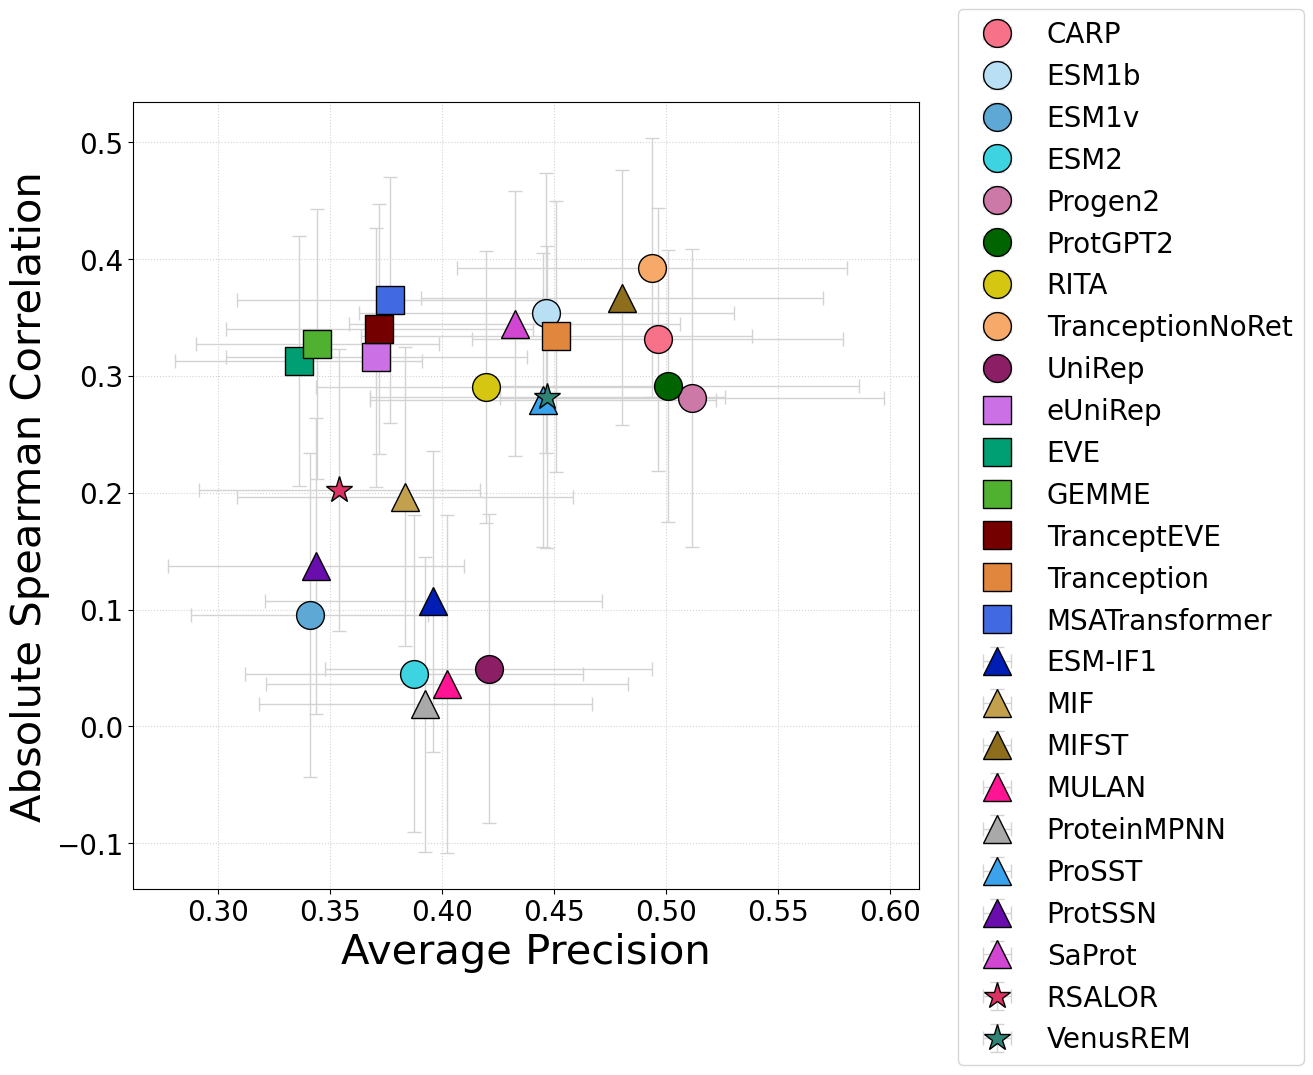

In [ ]:
# Plotting the model performances
for name in ['GmSuSy_Tm_single']:
    print(f'Plotting results for {name}')
    prizmplt.metrics(prizm, name)

Plotting results for GmSuSy_Tm_single correct models


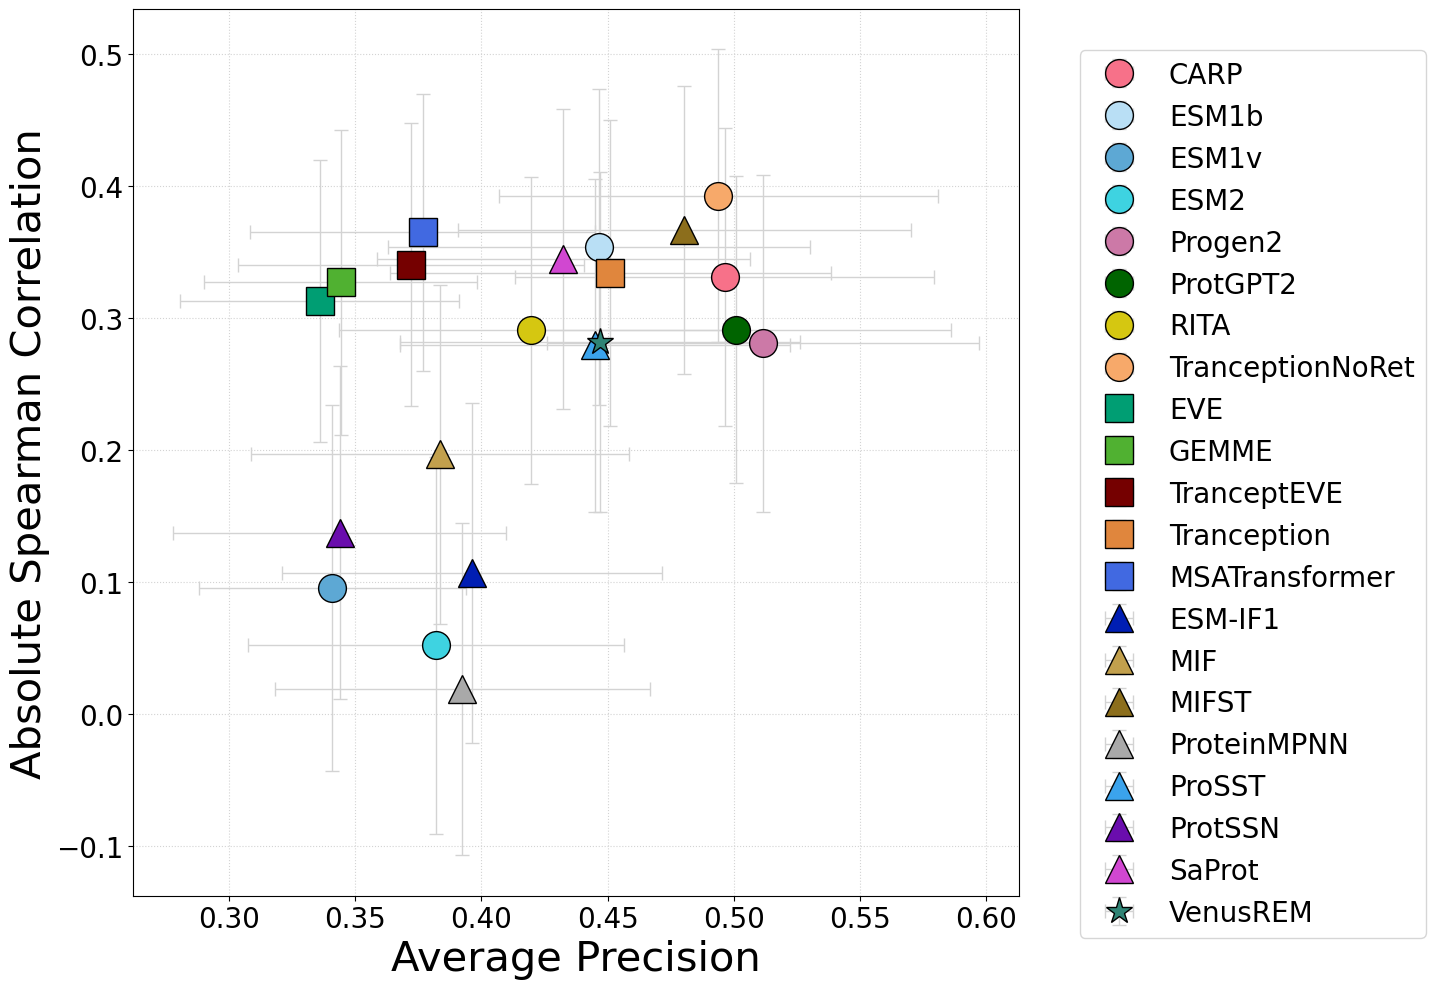

In [ ]:
# Plotting the model performances, with the best and worst models highlighted
for name in ['GmSuSy_Tm_single']:  
    print(f'Plotting results for {name} correct models')
    prizmplt.metrics(prizm, name, figsize=(14, 10), use_correct=True)

Plotting results for GmSuSy_Tm_single


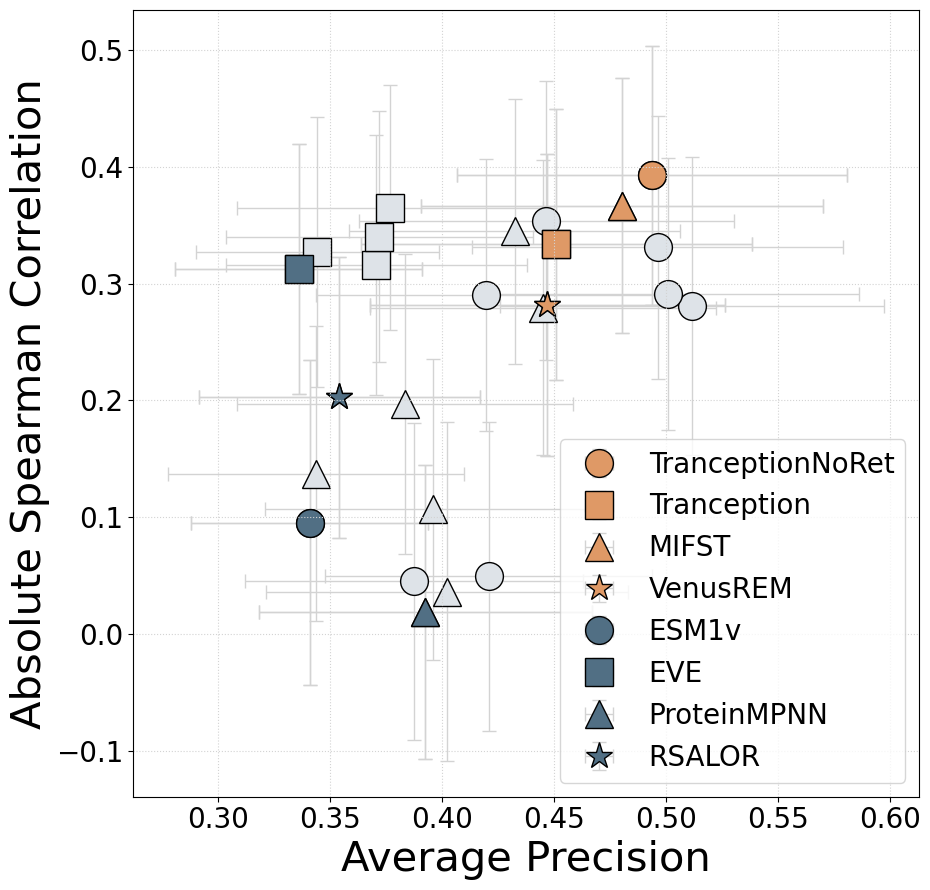

Plotting results for GmSuSy_Tm_single correct models


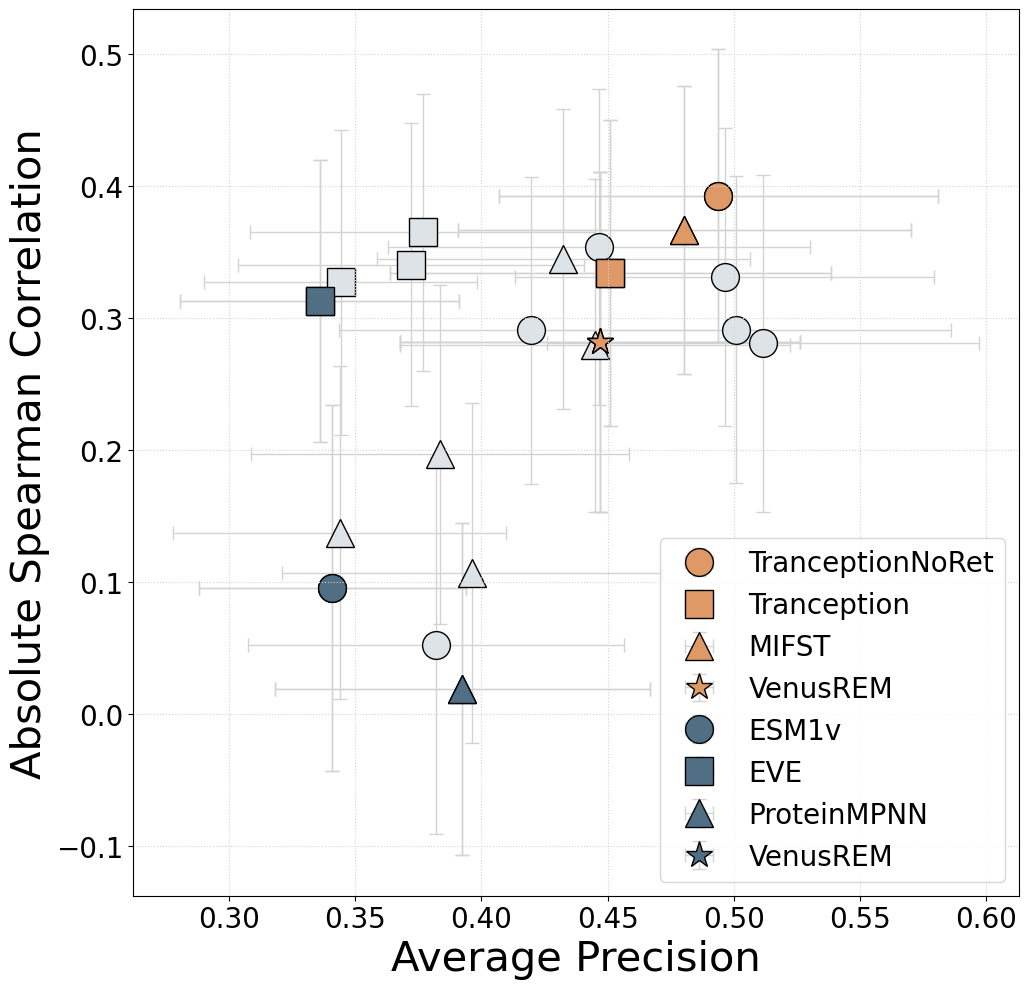

In [ ]:
# Plotting the model performances, with the best and worst models highlighted
for name in ['GmSuSy_Tm_single']:
    print(f'Plotting results for {name}')
    prizmplt.metrics_cat(prizm, name, legend_fontsize=20)

    print(f'Plotting results for {name} correct models')
    prizmplt.metrics_cat(prizm, name, figsize=(14, 10), use_correct=True,  legend_fontsize=20)

Plotting results for GmSuSy_Tm
Overall Model
Best Overall Model: ProtSSN


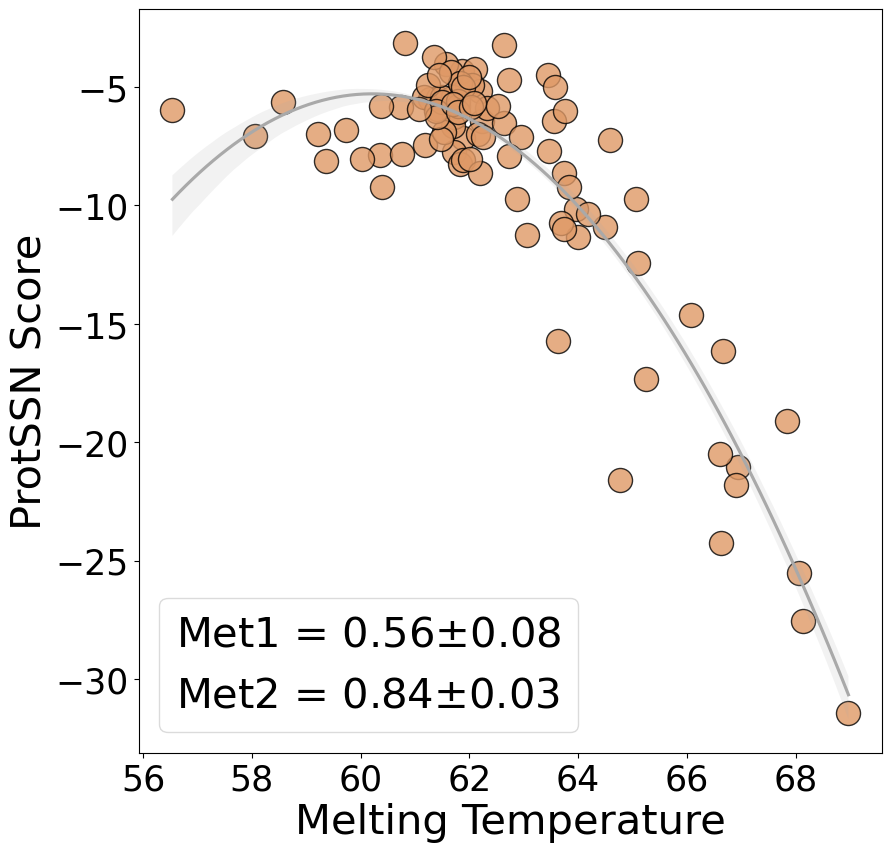

Worst Overall Model: MIF


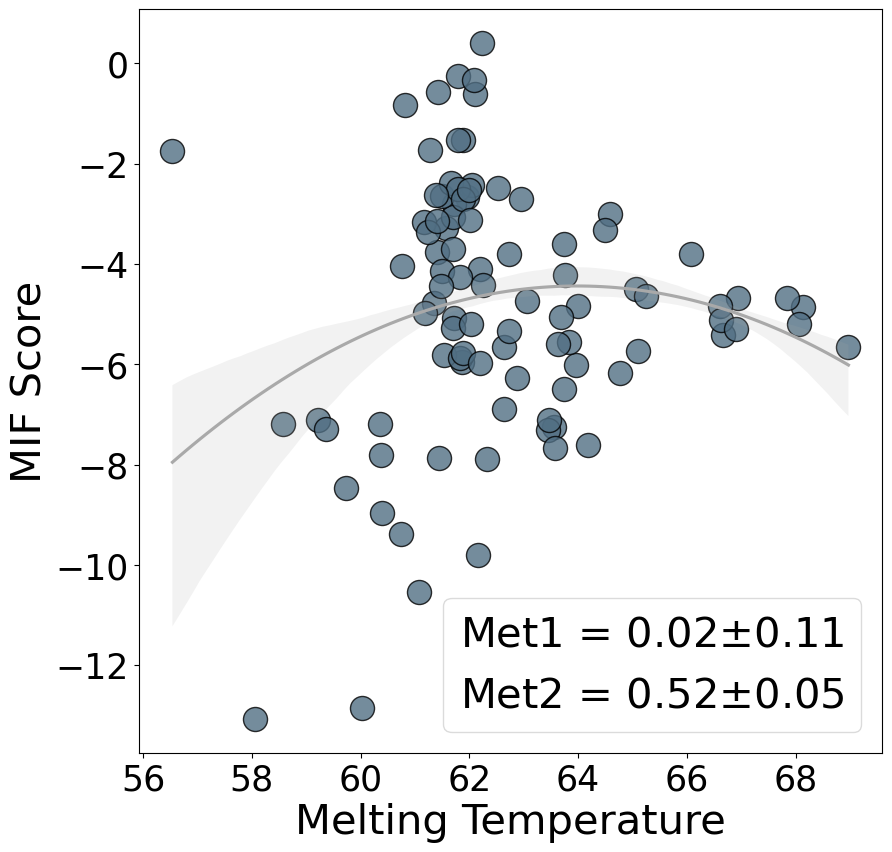

Sequence Model
Best Sequence Model: ProtGPT2


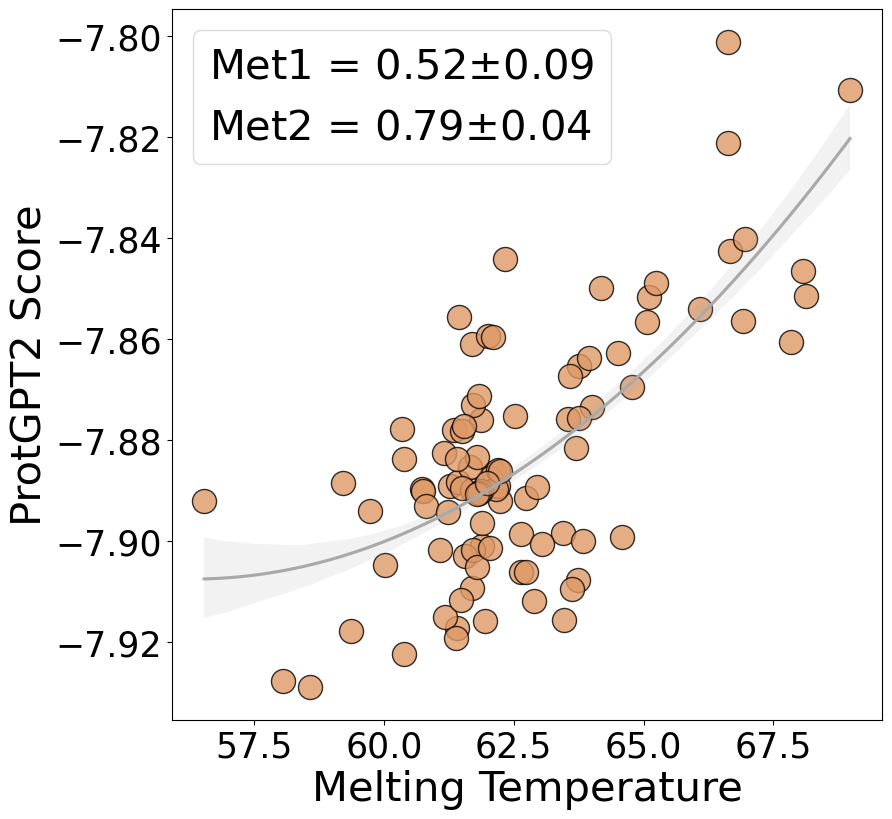

Worst Sequence Model: ESM1b


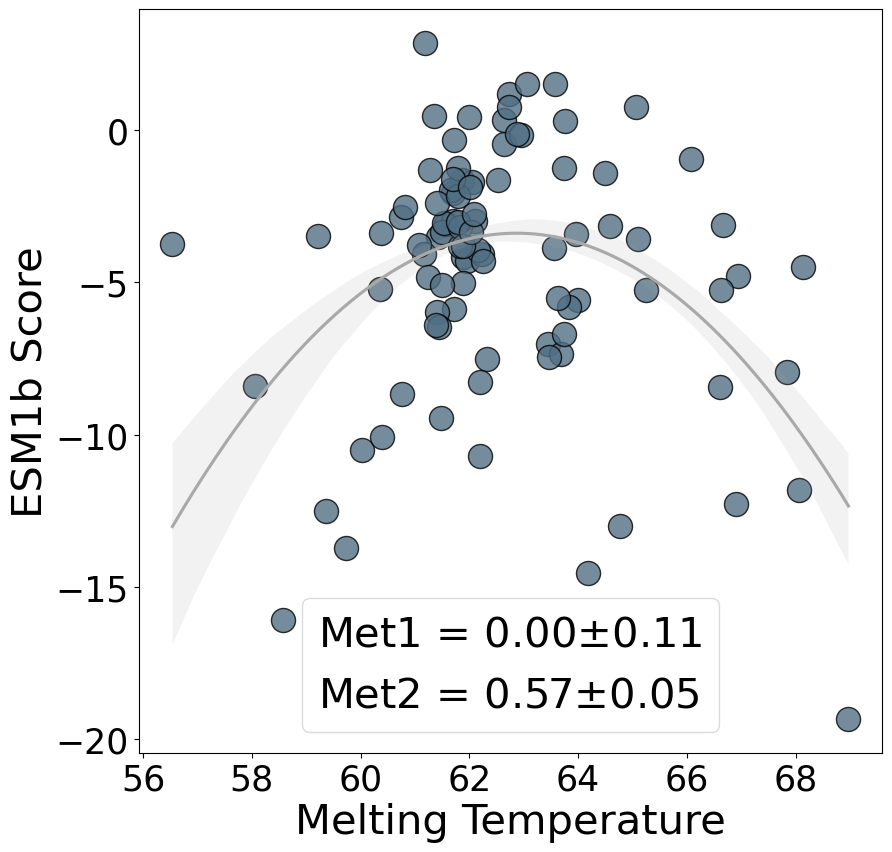

MSA Model
Best MSA Model: Tranception_L


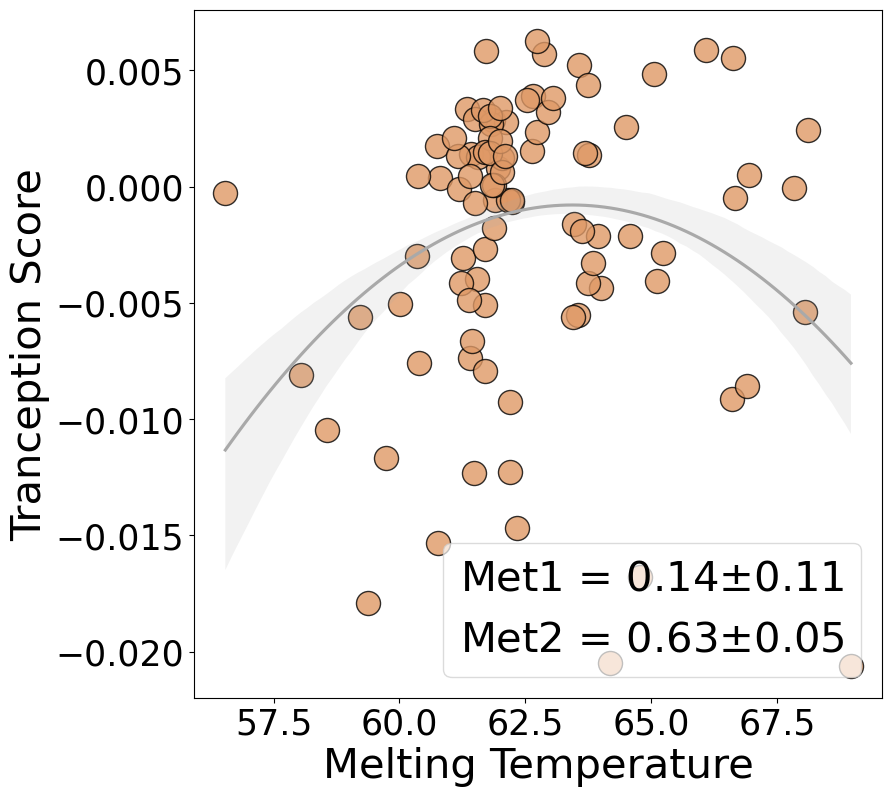

Worst MSA Model: MSATransformer


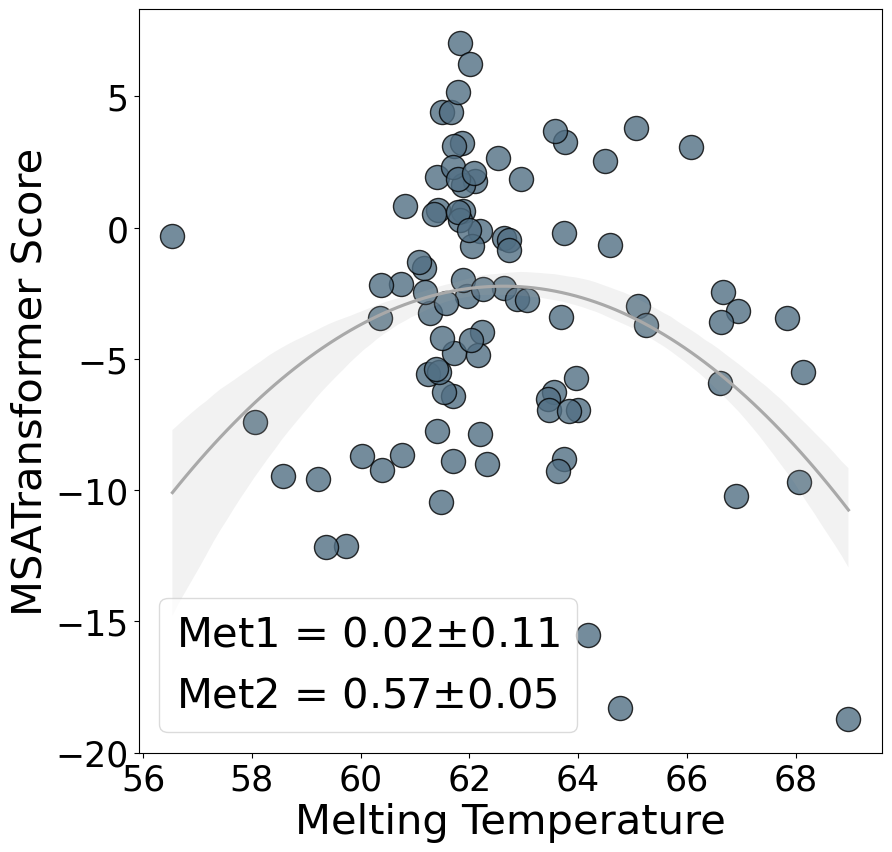

Structure Model
Best Structure Model: ProtSSN


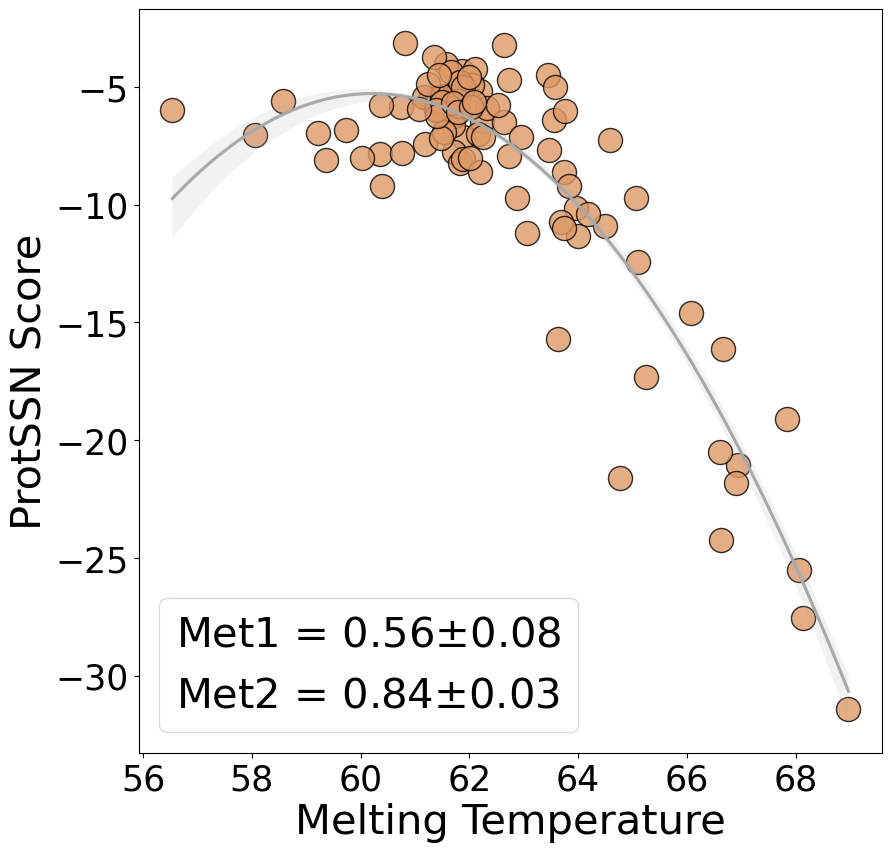

Worst Structure Model: MIF


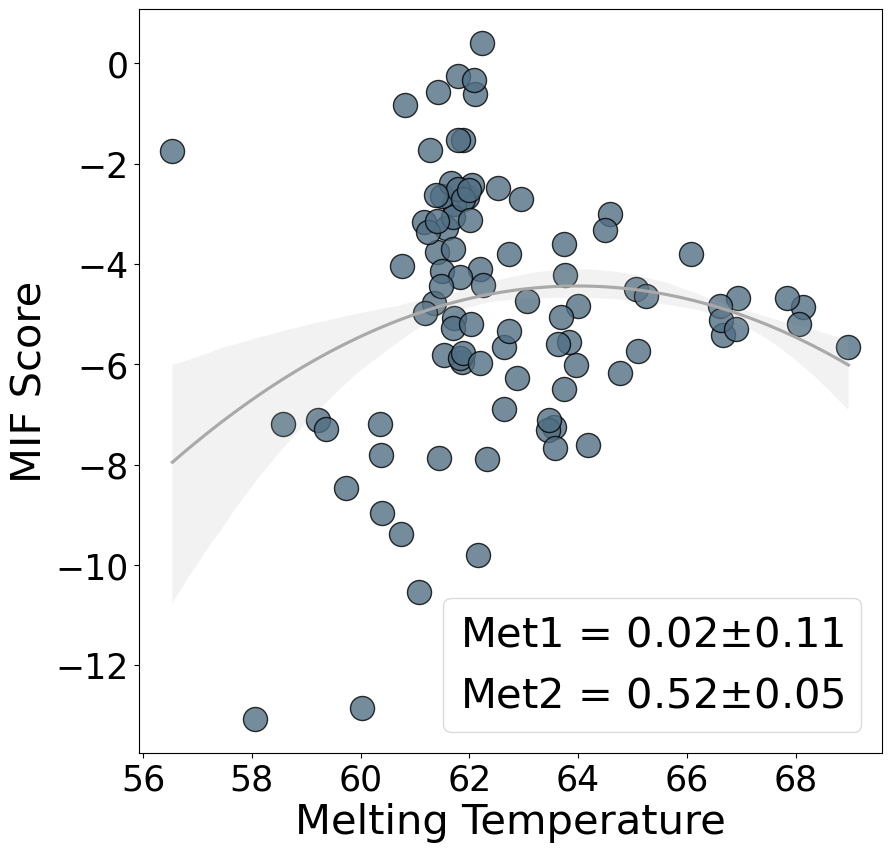

All features
Best Model using all features: VenusREM_20


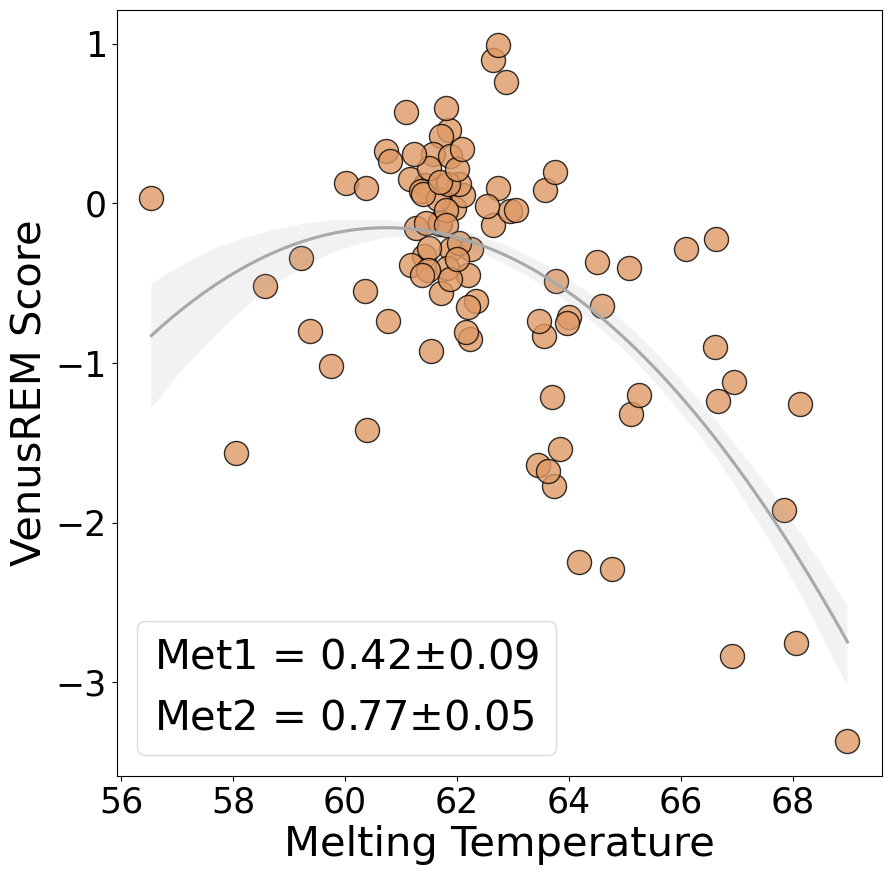

Worst Model using all features: RSALOR


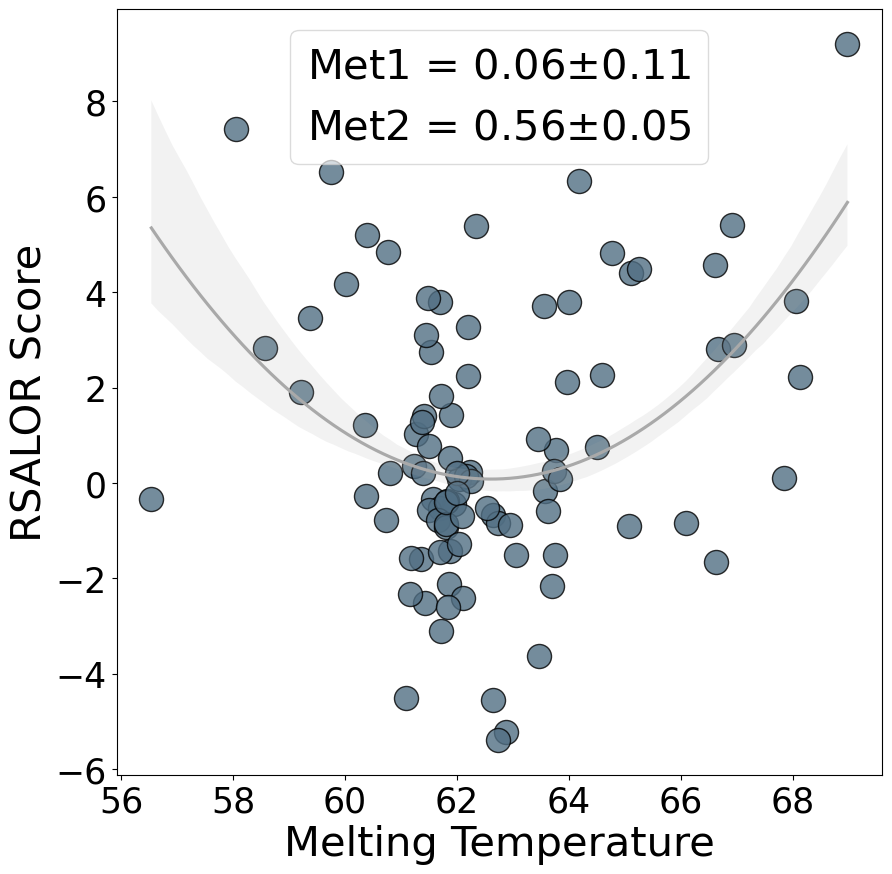

In [ ]:
# Plotting the performance of the best model
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
exp_property = 'Melting Temperature'
worst_color = '#516f84'
for name in lowN_name:
    print(f'Plotting results for {name}')

    print('Overall Model')
    best_ = prizm.best_models[name]['overall']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['overall']
    worst_score_name = worst_.split('_')[0]
    print('Best Overall Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Overall Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('Sequence Model')
    best_ = prizm.best_models[name]['sequence']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['sequence']
    worst_score_name = worst_.split('_')[0]
    print('Best Sequence Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Sequence Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('MSA Model')
    best_ = prizm.best_models[name]['MSA']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['MSA']
    worst_score_name = worst_.split('_')[0]
    print('Best MSA Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst MSA Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('Structure Model')
    best_ = prizm.best_models[name]['structure']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['structure']
    worst_score_name = worst_.split('_')[0]
    print('Best Structure Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Structure Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('All features')
    best_ = prizm.best_models[name]['all']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['all']
    worst_score_name = worst_.split('_')[0]
    print('Best Model using all features:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Model using all features:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)


Plotting results for GmSuSy_Tm_single
Overall Model
Best Overall Model: TranceptionNoRet_L


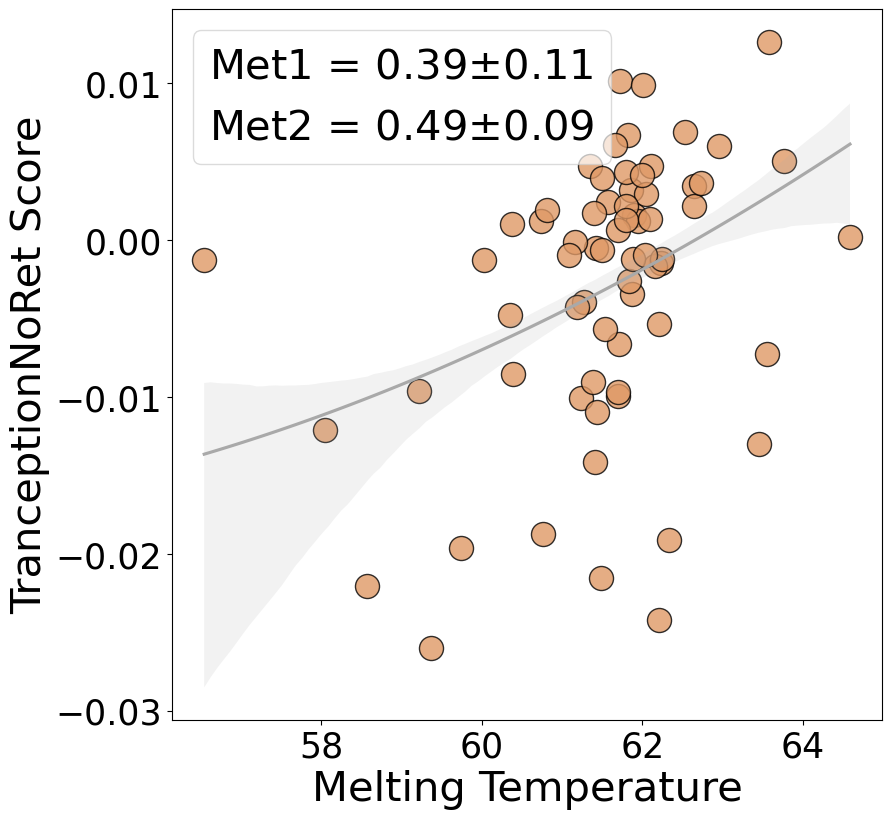

Worst Overall Model: ProteinMPNN


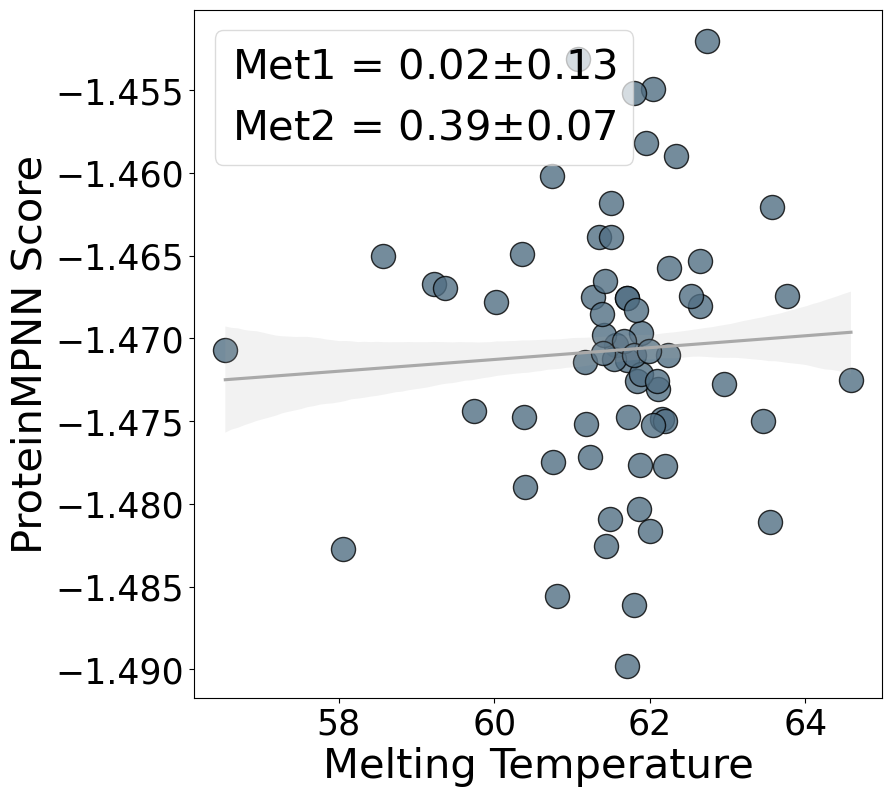

Sequence Model
Best Sequence Model: TranceptionNoRet_L


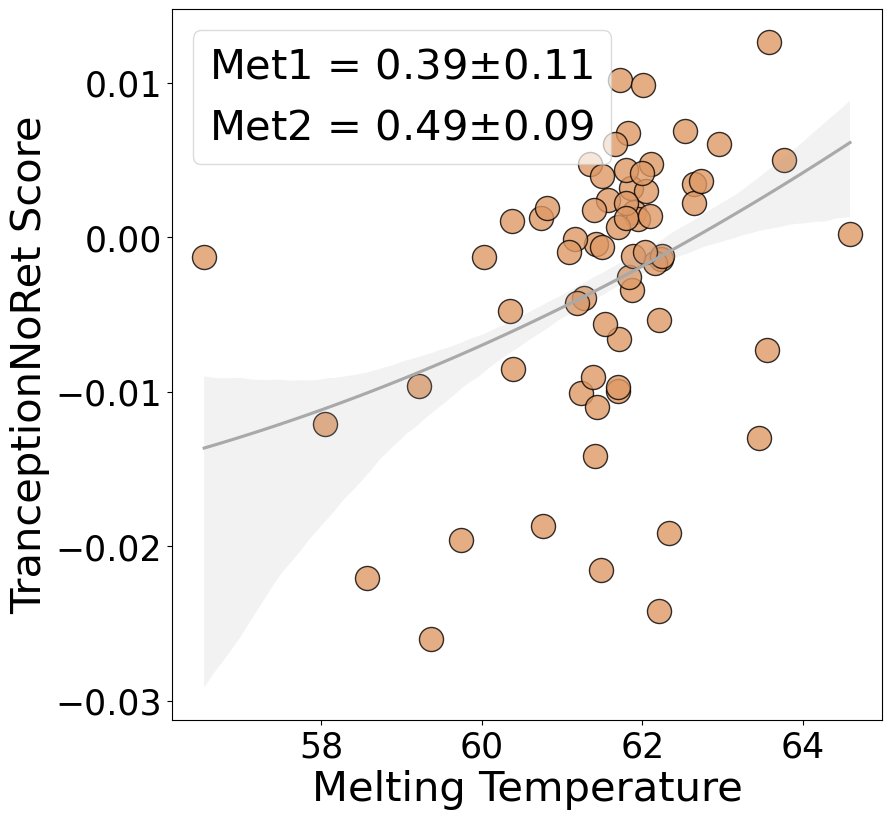

Worst Sequence Model: ESM1v


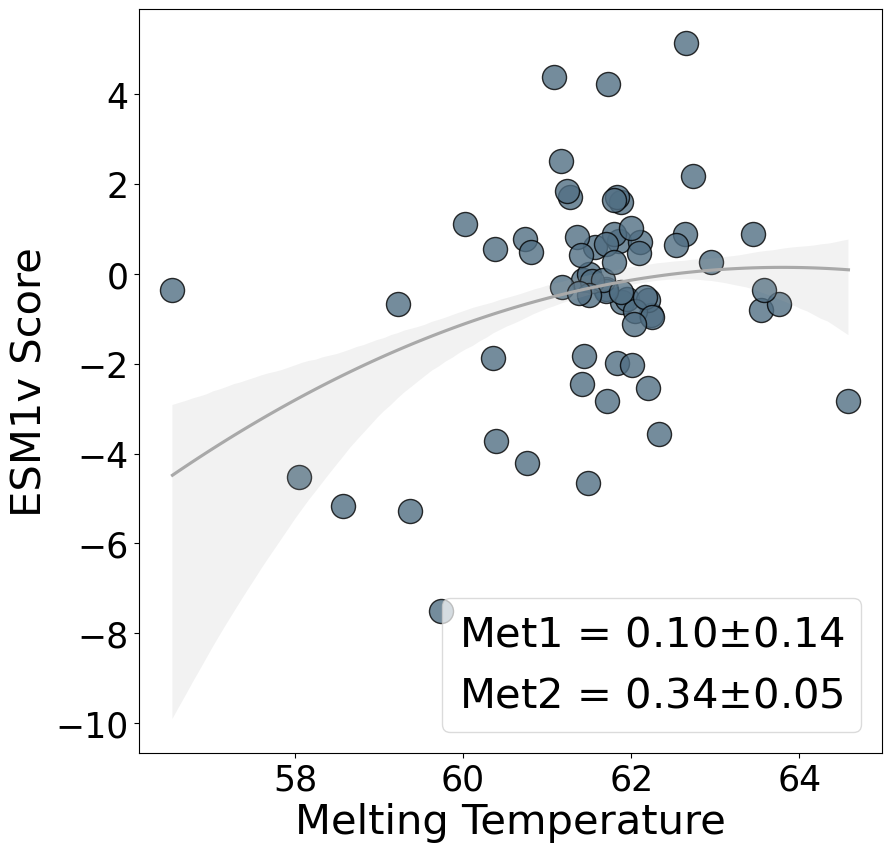

MSA Model
Best MSA Model: Tranception_L


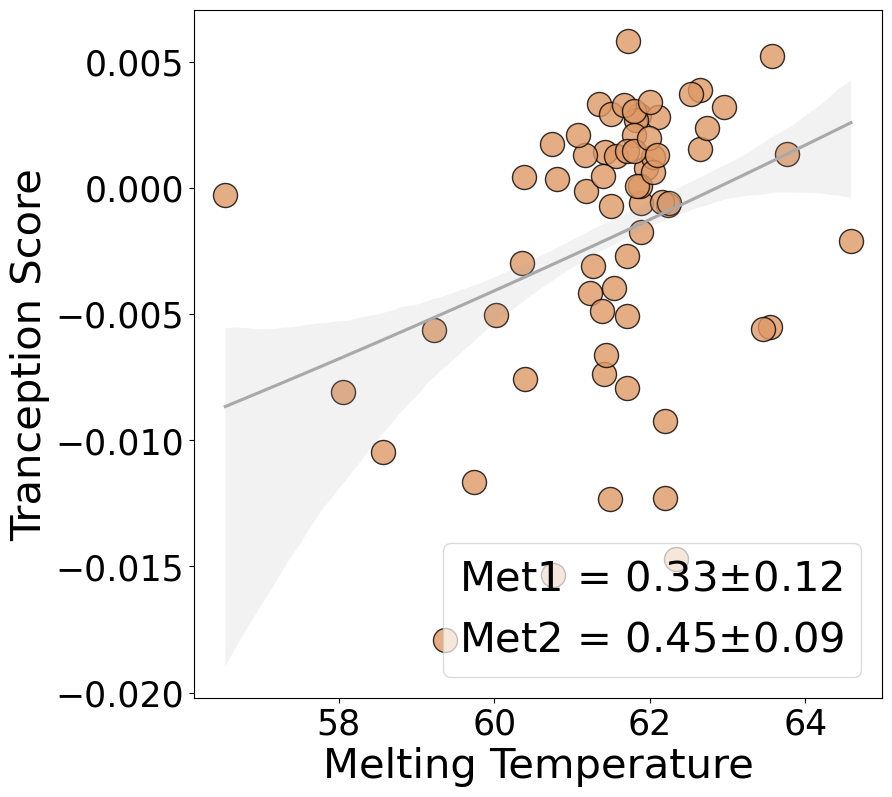

Worst MSA Model: EVE


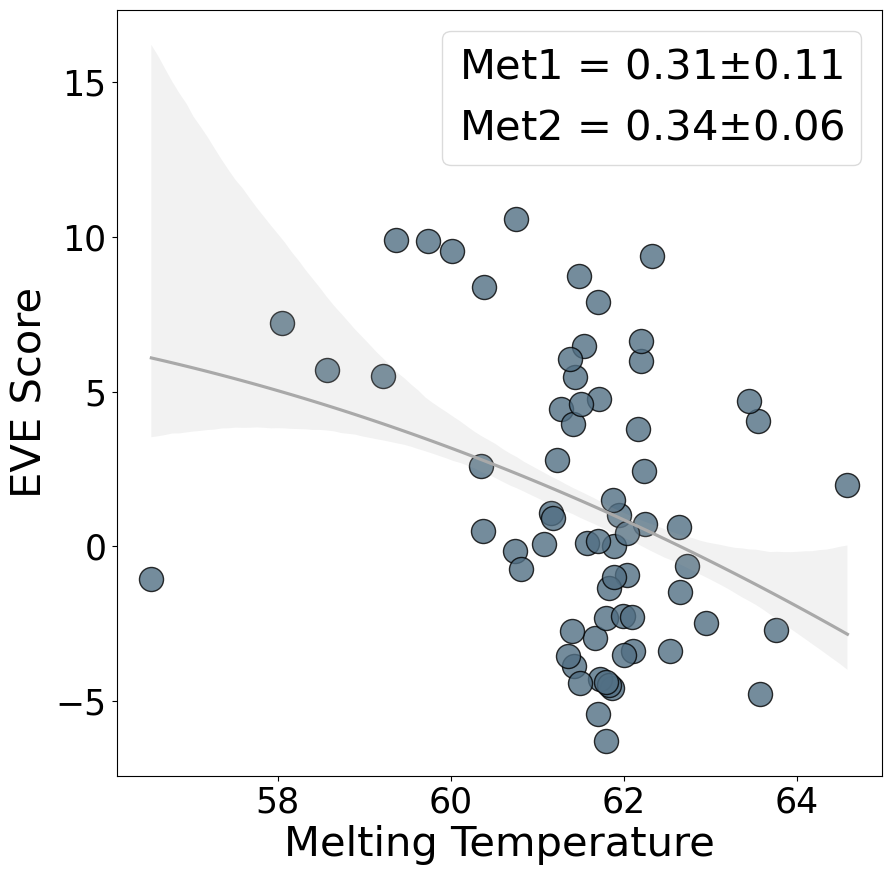

Structure Model
Best Structure Model: MIFST


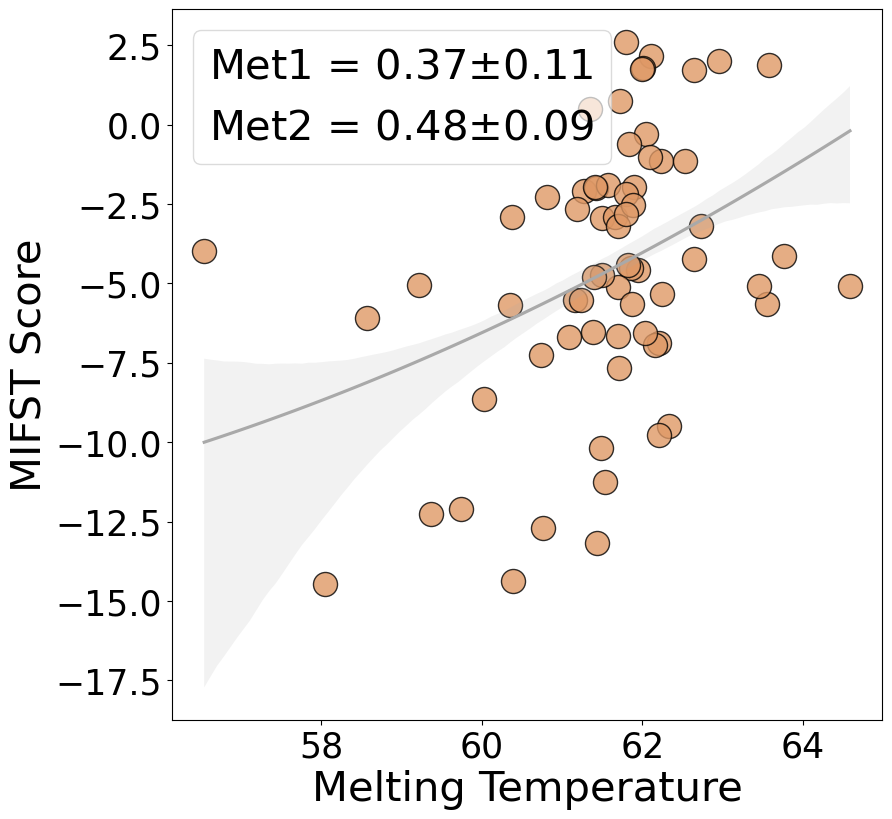

Worst Structure Model: ProteinMPNN


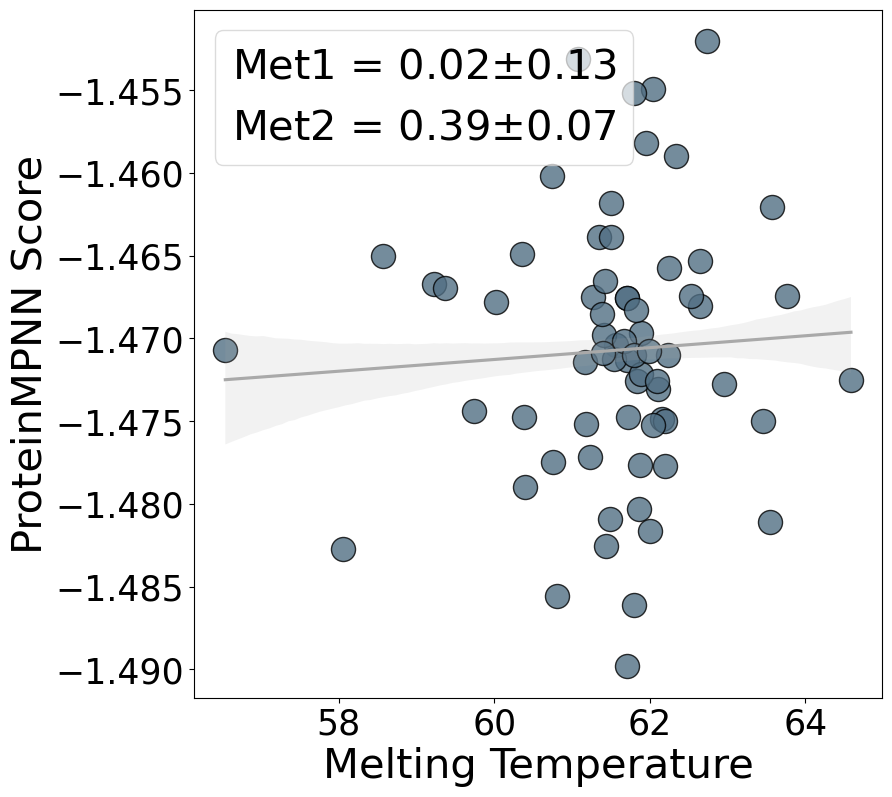

All features
Best Model using all features: VenusREM_2048


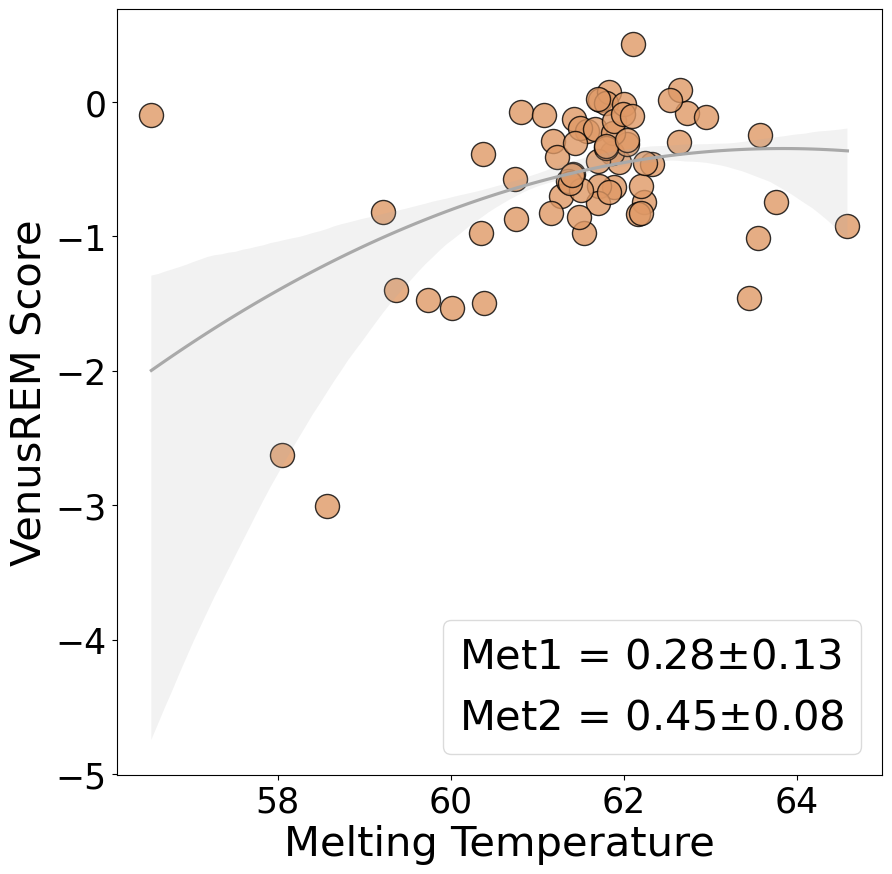

Worst Model using all features: RSALOR


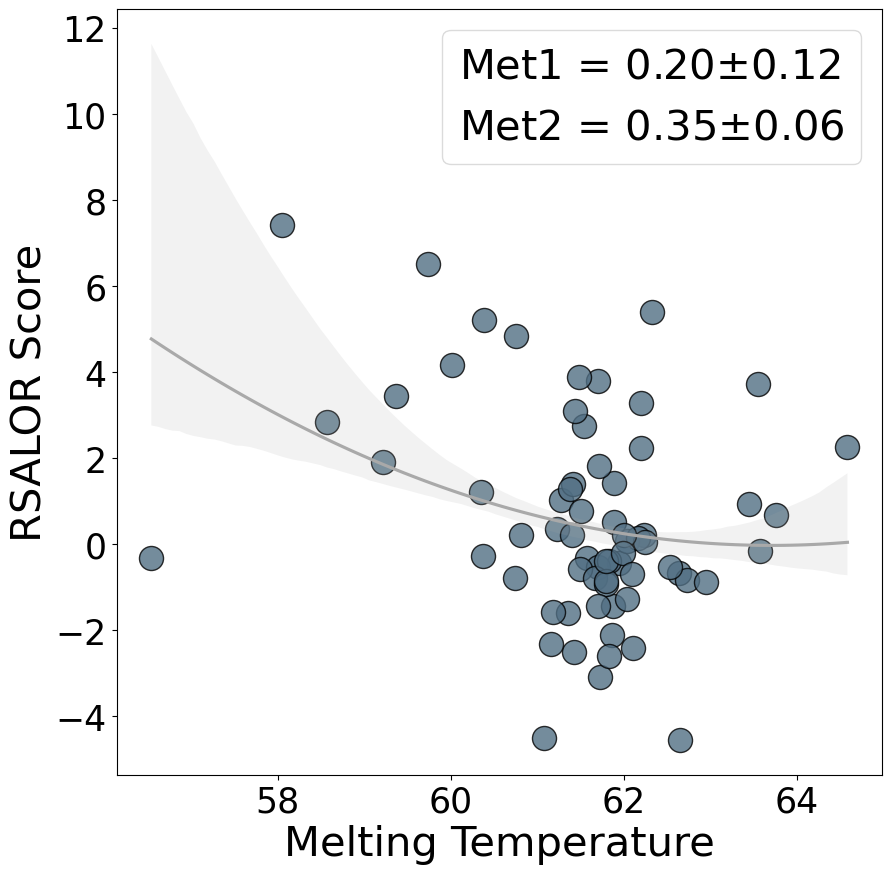

In [ ]:
# Plotting the performance of the best model
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
exp_property = 'Melting Temperature'
worst_color = '#516f84'
for name in lowN_name:
    name = f'{name}_single'
    print(f'Plotting results for {name}')

    print('Overall Model')
    best_ = prizm.best_models[name]['overall']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['overall']
    worst_score_name = worst_.split('_')[0]
    print('Best Overall Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Overall Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('Sequence Model')
    best_ = prizm.best_models[name]['sequence']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['sequence']
    worst_score_name = worst_.split('_')[0]
    print('Best Sequence Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Sequence Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('MSA Model')
    best_ = prizm.best_models[name]['MSA']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['MSA']
    worst_score_name = worst_.split('_')[0]
    print('Best MSA Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst MSA Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('Structure Model')
    best_ = prizm.best_models[name]['structure']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['structure']
    worst_score_name = worst_.split('_')[0]
    print('Best Structure Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Structure Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)

    print('All features')
    best_ = prizm.best_models[name]['all']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['all']
    worst_score_name = worst_.split('_')[0]
    print('Best Model using all features:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=True)
    print('Worst Model using all features:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=True)


# Variant Ranking - In-silico Library

## Make in-silico library

---

In [53]:
# Change the values of the following variables as needed
dataset_name = 'GmSuSy' # Name of the dataset
library_suffix = 'SMscan'
numb_mut = [1] # For both single and double mutants, use the format [1,2]
wt_seq = 'MATDRLTRVHSLRERLDETLTANRNEILALLSRIEAKGKGILQHHQVIAEFEEIPEENRQKLTDGAFGEVLRSTQEAIVLPPWVALAVRPRPGVWEYLRVNVHALVVEELQPAEYLHFKEELVDGSSNGNFVLELDFEPFNAAFPRPTLNKSIGNGVQFLNRHLSAKLFHDKESLHPLLEFLRLHSVKGKTLMLNDRIQNPDALQHVLRKAEEYLGTVPPETPYSEFEHKFQEIGLERGWGDNAERVLESIQLLLDLLEAPDPCTLETFLGRIPMVFNVVILSPHGYFAQDNVLGYPDTGGQVVYILDQVRALENEMLHRIKQQGLDIVPRILIITRLLPDAVGTTCGQRLEKVFGTEHSHILRVPFRTEKGIVRKWISRFEVWPYLETYTEDVAHELAKELQGKPDLIVGNYSDGNIVASLLAHKLGVTQCTIAHALEKTKYPESDIYWKKLEERYHFSCQFTADLFAMNHTDFIITSTFQEIAGSKDTVGQYESHTAFTLPGLYRVVHGIDVFDPKFNIVSPGADQTIYFPHTETSRRLTSFHPEIEELLYSSVENEEHICVLKDRSKPIIFTMARLDRVKNITGLVEWYGKNAKLRELVNLVVVAGDRRKESKDLEEKAEMKKMYGLIETYKLNGQFRWISSQMNRVRNGELYRVICDTRGAFVQPAVYEAFGLTVVEAMTCGLPTFATCNGGPAEIIVHGKSGFHIDPYHGDRAADLLVDFFEKCKLDPTHWDKISKAGLQRIEEKYTWQIYSQRLLTLTGVYGFWKHVSNLDRRESRRYLEMFYALKYRKLAESVPLAAE'

In [ ]:
# Generate the insilico library
insilico_library = prizm.insilico_library(dataset_name,numb_mut,wt_seq=wt_seq,custom_name=library_suffix)

## In silico library analysis

### Load dataset

---

In [13]:
# Change the values of the following variables as needed
dataset_name = 'GmSuSy'
library_suffix = 'SMscan'
model_list_selection = ['ProtGPT2','TranceptionNoRet','MSATransformer','MIFST','ProtSSN'] # Best models from each category
library_name = dataset_name+'_'+library_suffix+'_insilico_library'
wt_threshold = 62.0

In [ ]:
prizm.set_threshold(library_name,wt_threshold)
prizm.load_scores(library_name,model_list_selection,wt=True)

---

### Sort and Rank library

---

In [ ]:
best_single = [prizm.best_models['GmSuSy_Tm_single'][cat] for cat in ['overall','sequence','MSA','structure']]

In [26]:
model_select = best_single + ['ProtGPT2'] + ['ProtSSN']

In [ ]:
library_ranking = prizm.sorting_mutants(library_name,model_select,'ProtGPT2','../results/',wt=True)

---

### Plotting model predictions

---

In [33]:
# Change the values of the following variables as needed
model_1 = 'TranceptionNoRet_L'
model_3 = 'MSATransformer'
model_2 = 'MIFST'
model_labels = ['TranceptionNoRet (Sequence)','MIFST (Structure)','MSATransformer (MSA)']


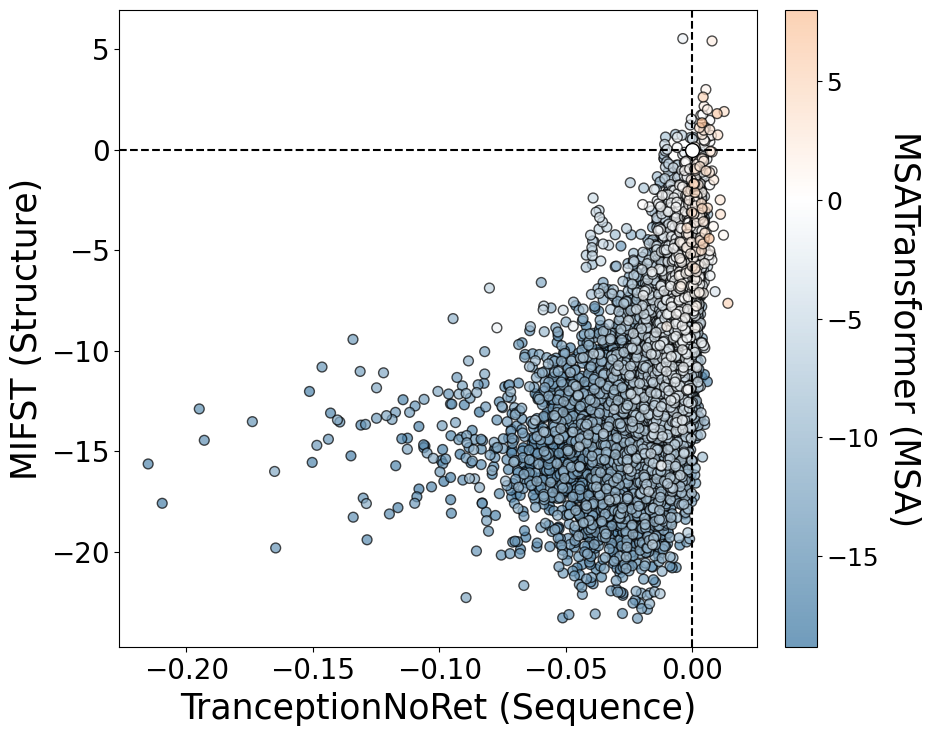

In [ ]:
prizmplt.best_models_scatter(prizm, library_name, [model_1,model_2,model_3], labels=model_labels,
                           colors = ['#34729F', 'white', '#F36906'],alpha=0.7, format='svg')